# The virtual photon: how a photon carries the electromagnetic force

Two electrons repel. In quantum electrodynamics (QED) that force is not action at a distance -- it is the
**exchange of a virtual photon**. One electron emits a photon, the other absorbs it, and the recoil at
each end *is* the force. The Feynman diagram for electron-electron scattering ($e^-e^-\to e^-e^-$,
Moller scattering) is two electron lines exchanging a single wavy photon line.

The photon in that diagram is **virtual**: it is *off the mass shell*. A real photon obeys $E=pc$, i.e.
its four-momentum satisfies $q^2=0$; the exchanged photon carries four-momentum $q=p_1-p_3$ with
$q^2\neq0$, so it could never exist as a free particle. It exists only for the brief instant permitted by
the energy-time uncertainty relation, and four-momentum **is** conserved exactly at every vertex -- the
"violation" is only of the free-particle energy-momentum relation, not of any conservation law.

This notebook makes that picture quantitative and self-contained:
- the photon **propagator** $\sim 1/q^2$ and its Fourier transform, which *is* the Coulomb potential;
- the massive generalization (Yukawa), showing **force range $\sim1/(\text{mediator mass})$**;
- the off-shell (spacelike) momentum transfer in $t$-channel scattering;
- the propagator squared reproducing the **Rutherford** $1/\sin^4(\theta/2)$ cross section;
- energy-time uncertainty setting the range; and a **drawn Feynman diagram**.

Self-contained: NumPy, SymPy, Pandas, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The propagator is the potential: Coulomb from photon exchange

The amplitude for exchanging a boson of mass $\mu$ carries the **propagator** $G(q)=1/(q^2+\mu^2)$
(natural units $\hbar=c=1$). Fourier-transforming to position space gives the potential the exchange
produces:
$$V(r)=\int\frac{d^3q}{(2\pi)^3}\,\frac{e^{\,i\mathbf q\cdot\mathbf r}}{q^2+\mu^2}
=\frac{e^{-\mu r}}{4\pi r}\quad\text{(Yukawa)},\qquad
\mu\to0:\;V(r)=\frac{1}{4\pi r}\;\text{(Coulomb)}.$$
Equivalently $V$ solves the screened-Poisson (Helmholtz) equation $(-\nabla^2+\mu^2)V=\delta^3(\mathbf r)$
-- the position-space statement that $1/(q^2+\mu^2)$ is the propagator. SymPy verifies the radial
solution; NumPy verifies the Fourier integral.

In [2]:
r, mu = sp.symbols('r mu', positive=True)
# For r>0, radial Laplacian: nabla^2 V = (1/r) (r V)''.  With w = r V, (-nabla^2+mu^2)V=0  <=>  w'' = mu^2 w.
w = sp.exp(-mu*r)/(4*sp.pi)                     # w = r V  for the Yukawa potential V=e^{-mu r}/(4 pi r)
assert sp.simplify(sp.diff(w, r, 2) - mu**2*w) == 0        # Yukawa solves (-nabla^2+mu^2)V=0 for r>0
w0 = sp.Rational(1,1)/(4*sp.pi)                             # mu->0 limit: w=1/(4pi) -> V=1/(4 pi r)
assert sp.simplify(sp.diff(w0, r, 2)) == 0                 # Coulomb solves Laplace eq for r>0
print("Yukawa V=e^{-mu r}/(4 pi r) solves (-nabla^2+mu^2)V=0;  Coulomb 1/(4 pi r) solves nabla^2 V=0")

Yukawa V=e^{-mu r}/(4 pi r) solves (-nabla^2+mu^2)V=0;  Coulomb 1/(4 pi r) solves nabla^2 V=0


In [3]:
# Numerical Fourier transform: V(r) = (1/(2 pi^2 r)) int_0^inf q sin(q r)/(q^2+mu^2) dq  =  e^{-mu r}/(4 pi r)
def V_fourier(rr, mval, qmax=1500.0, nq=600_000):
    q = np.linspace(1e-6, qmax, nq)
    integ = q*np.sin(q*rr)/(q**2 + mval**2)
    return np.trapz(integ, q)/(2*np.pi**2*rr) if hasattr(np,'trapz') else np.trapezoid(integ, q)/(2*np.pi**2*rr)
for mval, name in [(0.8, "Yukawa mu=0.8"), (1e-4, "Coulomb mu->0")]:
    rr = 1.3
    num = V_fourier(rr, mval)
    exact = np.exp(-mval*rr)/(4*np.pi*rr)
    print(f"{name:16s}: FT V({rr}) = {num:.5f}   exact e^(-mu r)/(4 pi r) = {exact:.5f}")
    assert abs(num-exact) < 1e-3

Yukawa mu=0.8   : FT V(1.3) = 0.02165   exact e^(-mu r)/(4 pi r) = 0.02164
Coulomb mu->0   : FT V(1.3) = 0.06116   exact e^(-mu r)/(4 pi r) = 0.06121


## Range of a force = Compton wavelength of the mediator

The exchanged mass sets the range: $V\propto e^{-\mu r}$ falls off over $R=1/\mu=\hbar/(Mc)$, the
**Compton wavelength** of the mediator. A **massless** photon ($M=0$) gives infinite range -- the
$1/r$ Coulomb law. A **massive** mediator gives a short-range force. This is Yukawa's 1935 argument
run in reverse: the ~1 fm range of the nuclear force implies a mediator of ~200 MeV (the pion, 140 MeV);
the ~$10^{-3}$ fm weak force implies the ~80 GeV $W$ boson.

In [4]:
hbarc = C.HBAR*C.C/C.E*1e9                       # hbar c in MeV.fm
print(f"hbar c = {hbarc:.3f} MeV.fm")
assert abs(hbarc - 197.33) < 0.1
rows = []
for name, M_MeV, force in [("photon", 0.0, "electromagnetic"),
                           ("pion (Yukawa)", 140.0, "nuclear (residual strong)"),
                           ("W boson", 80400.0, "weak")]:
    R = np.inf if M_MeV == 0 else hbarc/M_MeV        # range = hbar/(M c) in fm
    rows.append({"mediator": name, "mass [MeV]": M_MeV, "force": force,
                 "range hbar/Mc [fm]": ("infinite" if R==np.inf else f"{R:.4g}")})
print(pd.DataFrame(rows).to_string(index=False))
assert abs(hbarc/140.0 - 1.409) < 0.01                # pion -> ~1.4 fm nuclear range

hbar c = 197.327 MeV.fm
     mediator  mass [MeV]                     force range hbar/Mc [fm]
       photon         0.0           electromagnetic           infinite
pion (Yukawa)       140.0 nuclear (residual strong)              1.409
      W boson     80400.0                      weak           0.002454


## The exchanged photon is off-shell (virtual)

In elastic $e^-e^-$ scattering an electron of momentum $\mathbf k$ scatters by angle $\theta$ keeping
$|\mathbf k|$. The four-momentum handed to the photon is $q=p_1-p_3$; its invariant is the Mandelstam
variable $t=q^2=-4k^2\sin^2(\theta/2)<0$ (spacelike). A **real** photon has $q^2=0$; here $q^2<0$ for any
$\theta>0$, so the photon is **virtual** -- it can never satisfy $E=pc$. Four-momentum is still conserved
exactly at each vertex ($p_1=p_3+q$); only the free-particle relation is off. SymPy confirms $t<0$ and the
photon's non-zero invariant mass-squared.

In [5]:
k, theta = sp.symbols('k theta', positive=True)
t = -4*k**2*sp.sin(theta/2)**2                    # Mandelstam t = q^2 for elastic scattering
assert sp.simplify(t) == -4*k**2*sp.sin(theta/2)**2
# q^2 = t < 0 for 0<theta<pi (spacelike => virtual); a real photon would need q^2=0
val = t.subs({k:1, theta:sp.pi/2})
print(f"q^2 = t = -4 k^2 sin^2(theta/2);  at theta=90deg, k=1:  q^2 = {float(val):.3f}  (<0 => virtual)")
assert val < 0

q^2 = t = -4 k^2 sin^2(theta/2);  at theta=90deg, k=1:  q^2 = -2.000  (<0 => virtual)


## The propagator squared is the Rutherford cross section

The scattering amplitude is (vertex)$\times$(propagator)$\times$(vertex) $\sim e^2/q^2=e^2/t$. The cross
section is $|\mathcal M|^2\sim e^4/t^2$. Substituting $t=-4k^2\sin^2(\theta/2)$,
$$\frac{d\sigma}{d\Omega}\propto\frac{1}{t^2}=\frac{1}{16k^4\sin^4(\theta/2)}\propto\frac{1}
{\sin^4(\theta/2)},$$
the **Rutherford law**. The famous $1/\sin^4(\theta/2)$ that Rutherford measured off gold foil is
nothing but the **square of the $1/q^2$ virtual-photon propagator**. SymPy verifies the identity;
NumPy plots the steep forward rise.

In [6]:
prop_sq = 1/t**2
rutherford = 1/(16*k**4*sp.sin(theta/2)**4)
assert sp.simplify(prop_sq - rutherford) == 0        # 1/q^4  ==  1/sin^4(theta/2) law
print("1/t^2 = 1/(16 k^4 sin^4(theta/2))  ->  dsigma/dOmega ~ 1/sin^4(theta/2)  (Rutherford)")
th = np.linspace(np.deg2rad(5), np.deg2rad(175), 400)
dsig = 1/np.sin(th/2)**4
print(f"cross section ratio, 10deg vs 90deg: {(1/np.sin(np.deg2rad(10)/2)**4)/(1/np.sin(np.deg2rad(90)/2)**4):.0f}x")

1/t^2 = 1/(16 k^4 sin^4(theta/2))  ->  dsigma/dOmega ~ 1/sin^4(theta/2)  (Rutherford)
cross section ratio, 10deg vs 90deg: 4333x


## Energy-time uncertainty: how the virtual photon is allowed to exist

The virtual photon violates $E=pc$ by an amount $\Delta E$, so it can exist only for $\Delta t\sim\hbar/
\Delta E$ (energy-time uncertainty), reaching a distance $R\sim c\,\Delta t\sim\hbar c/\Delta E$. For a
mediator of mass $M$ the minimum off-shell cost is $\Delta E\sim Mc^2$, giving $R\sim\hbar/(Mc)$ -- the
same Compton-wavelength range as the Yukawa fall-off, now from the uncertainty principle. The photon's
$M=0$ makes $R\to\infty$: the electromagnetic force has unlimited range because its mediator is massless.


In [7]:
for name, M_MeV in [("pion", 140.0), ("W boson", 80400.0)]:
    dE = M_MeV                                        # min off-shell energy ~ M c^2 (MeV)
    R = hbarc/dE                                      # reach in fm
    print(f"{name:8s}: Delta E ~ {M_MeV:>7.1f} MeV  ->  reach hbar c/Delta E = {R:.4g} fm")
print("photon:  Delta E -> 0 (massless)  ->  reach -> infinity  (long-range Coulomb)")

pion    : Delta E ~   140.0 MeV  ->  reach hbar c/Delta E = 1.409 fm
W boson : Delta E ~ 80400.0 MeV  ->  reach hbar c/Delta E = 0.002454 fm
photon:  Delta E -> 0 (massless)  ->  reach -> infinity  (long-range Coulomb)


## Plots: the Rutherford rise and the Feynman diagram

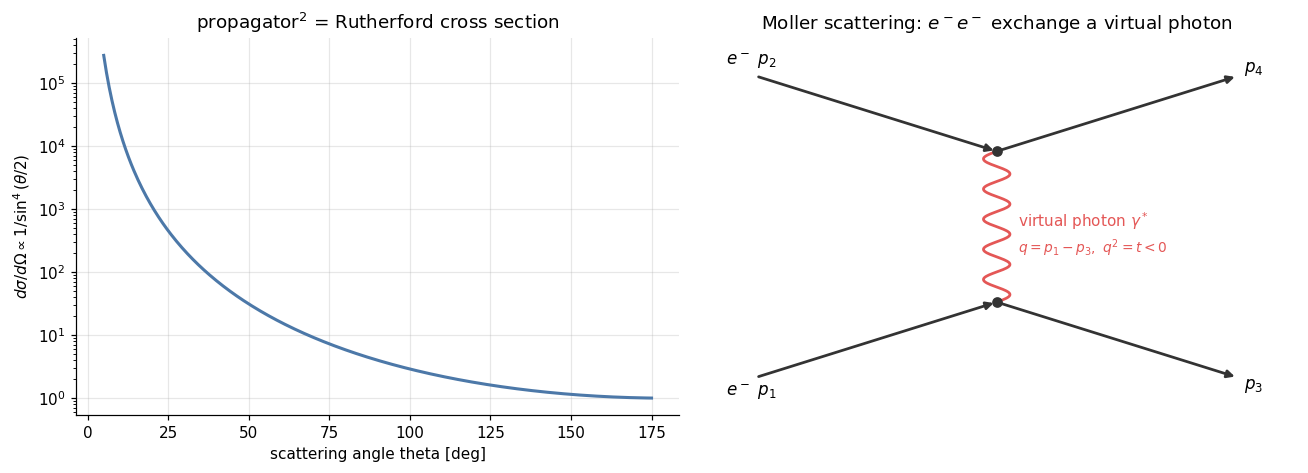

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

# (left) Rutherford cross section from the squared propagator
ax[0].semilogy(np.rad2deg(th), dsig, color="#4C78A8", lw=2)
ax[0].set_xlabel("scattering angle theta [deg]"); ax[0].set_ylabel(r"$d\sigma/d\Omega \propto 1/\sin^4(\theta/2)$")
ax[0].set_title("propagator$^2$ = Rutherford cross section")

# (right) the t-channel Feynman diagram: two electrons exchange a virtual photon
axd = ax[1]; axd.set_xlim(0, 10); axd.set_ylim(0, 10); axd.axis("off")
axd.set_title("Moller scattering: $e^-e^-$ exchange a virtual photon")
arrow = dict(arrowstyle="-|>", color="#333", lw=1.8)
# electron fermion lines: incoming from the left to a vertex, then outgoing to the right
# lower line: p1 -> vertex(5,3) -> p3 ;  upper line: p2 -> vertex(5,7) -> p4
axd.annotate("", xy=(5,3), xytext=(1,1), arrowprops=arrow)   # p1 in
axd.annotate("", xy=(9,1), xytext=(5,3), arrowprops=arrow)   # p3 out
axd.annotate("", xy=(5,7), xytext=(1,9), arrowprops=arrow)   # p2 in
axd.annotate("", xy=(9,9), xytext=(5,7), arrowprops=arrow)   # p4 out
axd.text(0.5,0.5,"$e^-\\ p_1$",fontsize=11); axd.text(9.1,0.7,"$p_3$",fontsize=11)
axd.text(0.5,9.3,"$e^-\\ p_2$",fontsize=11); axd.text(9.1,9.1,"$p_4$",fontsize=11)
# wavy virtual-photon line between the two vertices (5,3)-(5,7)
yy = np.linspace(3, 7, 200); xx = 5 + 0.22*np.sin(2*np.pi*(yy-3)/0.8)
axd.plot(xx, yy, color="#E45756", lw=1.8)
axd.text(5.35, 5.0, r"virtual photon $\gamma^*$", color="#E45756", fontsize=10)
axd.text(5.35, 4.3, r"$q=p_1-p_3,\ q^2=t<0$", color="#E45756", fontsize=9)
for vx,vy in [(5,3),(5,7)]:
    axd.plot(vx,vy,'o',color="#333",ms=6)            # QED vertices (coupling ~ e)
plt.tight_layout(); plt.show()

## Summary

- The electromagnetic force between two electrons is the **exchange of a virtual photon**; its Feynman
  diagram is two electron lines joined by one photon line, with a coupling $\sim e$ at each vertex.
- The photon carries the **propagator** $1/q^2$; its Fourier transform **is** the Coulomb potential
  $1/(4\pi r)$ (SymPy: Yukawa/Coulomb solve the screened-Poisson equation; NumPy: the Fourier integral).
- A massive mediator gives $e^{-\mu r}/(4\pi r)$ with range $\hbar/(Mc)$ -- **force range = mediator
  Compton wavelength** (photon massless $\Rightarrow$ infinite-range Coulomb; pion $\Rightarrow$ ~1.4 fm).
- The exchanged photon is **off-shell**, $q^2=t=-4k^2\sin^2(\theta/2)<0$: it can never be a free photon.
  Four-momentum is conserved exactly at each vertex; only $E=pc$ is (briefly) violated, licensed by
  energy-time uncertainty $\Delta t\sim\hbar/\Delta E$.
- The **square of the propagator** reproduces the **Rutherford** $1/\sin^4(\theta/2)$ cross section --
  the $1/q^2$ virtual photon is directly visible in a scattering measurement.

Subject-verb-object: the electron emits a virtual photon; the propagator sets the potential; the mediator
mass sets the range; the uncertainty principle licenses the exchange. (Like the Dirac notebook, this is
particle physics on its own terms -- not a dependency of the classical dispersion phase-recovery
pipeline.)